# Week 2 · Notebook 1 — The Metropolis Rule and Simulated Annealing

**Goals**
- Place simulated annealing (SA) historically: the Metropolis algorithm (Metropolis, Rosenbluth, Rosenbluth, Teller
  & Teller 1953), its generalisation by Hastings (1970), and its reinvention as an optimiser by Kirkpatrick, Gelatt &
  Vecchi (1983) and, independently, Černý (1985).
- Define the Boltzmann distribution and the Metropolis acceptance rule precisely, and **prove** that the Metropolis
  chain satisfies detailed balance with respect to the Boltzmann distribution.
- **Verify** this on a finite landscape: build the exact transition matrix, extract its stationary vector by an
  eigen-decomposition (independently of the Boltzmann formula), and compare with both the closed form and a long
  simulation. Watch the theorem *fail* for an asymmetric proposal without the Hastings correction.
- Measure how mixing slows as $T \to 0$ (spectral gap $\asymp e^{-m/T}$) and how the Boltzmann distribution
  concentrates on the global optima.
- Write a clean, generic SA implementation and test it against an exact solver (QAP by enumeration).

**Prerequisites:** Week 1 (landscapes, neighbourhoods, local search, evaluation budgets); finite Markov chains
(transition matrices, stationary distributions).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import BudgetedObjective, BudgetExhausted, random_qap, qap_cost, qap_brute_force, PALETTE

## 1. From statistical mechanics to optimisation — a short history

* **1953 — Metropolis et al.**, *Equation of State Calculations by Fast Computing Machines* (J. Chem. Phys. 21:1087).
  To compute equilibrium averages of a system of particles at temperature $T$, they proposed a random-walk
  *Markov chain* whose long-run frequencies are the Boltzmann distribution, instead of sampling configurations
  uniformly and re-weighting. The key ingredient is the acceptance rule now carrying Metropolis' name.
* **1970 — Hastings** (Biometrika 57:97) generalised the rule to asymmetric proposal distributions
  (Metropolis–Hastings). Pincus (1970, *Operations Research*) already used Metropolis sampling at low temperature
  to approximate a minimiser.
* **1983 — Kirkpatrick, Gelatt & Vecchi**, *Optimization by Simulated Annealing* (Science 220:671), turned the
  sampler into a general-purpose optimiser: read the objective $f$ as an energy, run the Metropolis chain and lower
  the temperature slowly, as a metallurgist anneals a metal to reach a low-energy crystalline state. They applied it
  to chip placement, wiring and the TSP.
* **1985 — Černý** (J. Optim. Theory Appl. 45:41) published the same idea independently for the TSP
  (a technical report circulated in 1982).
* **1984–1988 — convergence theory.** Geman & Geman (1984) gave a logarithmic schedule sufficient for convergence;
  Hajek (1988) gave the exact necessary and sufficient constant (Notebook 2).

Metaphor-free, SA is a **single-point trajectory method** with

| Mechanism | SA choice |
|---|---|
| Representation | any finite (or continuous) search space $S$ |
| Variation | draw one random neighbour $y \sim q(x, \cdot)$ from a neighbourhood $N(x)$ |
| Acceptance | Metropolis: always accept improvements, accept a worsening $\Delta\gt 0$ with probability $e^{-\Delta/T}$ |
| Control | a temperature *schedule* $T_1 \ge T_2 \ge \dots \to 0$ |
| Memory | none besides the current point (and the best-so-far, reported at the end) |

## 2. The Boltzmann distribution

Let $S$ be finite, $E: S \to \mathbb{R}$ the energy (= objective to minimise), $E^{\ast} = \min E$ and
$S^{\ast} = \arg\min E$. For temperature $T \gt 0$ the **Boltzmann (Gibbs) distribution** is

$$\pi_T(x) = \frac{e^{-E(x)/T}}{Z_T}, \qquad Z_T = \sum_{y \in S} e^{-E(y)/T}.$$

**Proposition 1 (limits).** As $T \to \infty$, $\pi_T$ tends to the uniform distribution on $S$; as $T \to 0$,
$\pi_T$ tends to the uniform distribution on $S^{\ast}$.

*Proof.* $\pi_T(x)/\pi_T(x^{\ast}) = e^{-(E(x) - E^{\ast})/T}$ for $x^{\ast} \in S^{\ast}$. As $T\to 0$ this is $1$ for
$x \in S^{\ast}$ and $\to 0$ otherwise; normalising gives $\pi_T(x) \to \mathbf{1}[x\in S^{\ast}]/|S^{\ast}|$. As
$T \to\infty$ every ratio tends to $1$. $\square$

**Proposition 2 (mean energy is increasing).** $\frac{d}{dT}\langle E\rangle_T = \mathrm{Var}_T(E)/T^2 \ge 0$
(the *heat capacity*).

*Proof.* With $\beta = 1/T$, $\langle E\rangle = -\partial_\beta \log Z$ and $\partial_\beta \langle E\rangle =
-\mathrm{Var}(E)$; the chain rule $d\beta/dT = -1/T^2$ finishes it. $\square$

Kirkpatrick et al. used the heat-capacity peak as a signature of a "phase transition" where the schedule should
be slowest. We validate Proposition 2 by finite differences below.

Our test landscape is a $5\times 5$ grid with 4-neighbour moves, integer energies, **two** tied global minima
(energy 0 at the bottom corners) and three non-global local minima.

In [2]:
E_grid = np.array([[4, 3, 5, 6, 2],
                   [3, 1, 4, 5, 3],
                   [5, 4, 6, 4, 5],
                   [6, 5, 3, 2, 4],
                   [0, 4, 5, 3, 0]], dtype=float)
NR, NC = E_grid.shape
E = E_grid.ravel()
n_states = E.size
nbrs = [[] for _ in range(n_states)]
for r in range(NR):
    for c in range(NC):
        for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            if 0 <= r + dr < NR and 0 <= c + dc < NC:
                nbrs[r * NC + c].append((r + dr) * NC + (c + dc))
deg = np.array([len(v) for v in nbrs])


def boltzmann(E, T):
    """Closed-form Boltzmann distribution (shifted by min E for numerical stability)."""
    w = np.exp(-(E - E.min()) / T)
    return w / w.sum()


local_min = [i for i in range(n_states) if all(E[j] > E[i] for j in nbrs[i])]
global_min = list(np.flatnonzero(E == E.min()))
print("local minima (state: energy):", {i: float(E[i]) for i in local_min})
print("global minima:", [int(i) for i in global_min], " degrees range:", deg.min(), "to", deg.max())

# Proposition 2: d<E>/dT = Var(E)/T^2, checked by a central finite difference
for T in (0.5, 1.0, 3.0):
    h = 1e-5
    dE_dT = (boltzmann(E, T + h) @ E - boltzmann(E, T - h) @ E) / (2 * h)
    p = boltzmann(E, T)
    check_close(dE_dT, (p @ E**2 - (p @ E) ** 2) / T**2, f"heat capacity identity at T={T}", atol=1e-6)

local minima (state: energy): {4: 2.0, 6: 1.0, 18: 2.0, 20: 0.0, 24: 0.0}
global minima: [20, 24]  degrees range: 2 to 4
[PASS] heat capacity identity at T=0.5: got 0.737698, expected 0.737698
[PASS] heat capacity identity at T=1.0: got 1.617595, expected 1.617595
[PASS] heat capacity identity at T=3.0: got 0.387301, expected 0.387301


## 3. The Metropolis and Metropolis–Hastings rules

Let $q(x, y)$ be a proposal kernel on $S$ (e.g. "pick a random neighbour"). From the current state $x$, draw
$y \sim q(x,\cdot)$ and move to $y$ with probability

$$\alpha_T(x, y) = \min\Big(1,\; \frac{\pi_T(y)\, q(y, x)}{\pi_T(x)\, q(x, y)}\Big)
  = \min\Big(1,\; e^{-(E(y)-E(x))/T}\,\frac{q(y,x)}{q(x,y)}\Big),$$

otherwise stay at $x$. For a **symmetric** proposal ($q(x,y) = q(y,x)$) the ratio of $q$'s cancels and we obtain the
original **Metropolis rule** $\alpha_T = \min(1, e^{-\Delta/T})$, $\Delta = E(y) - E(x)$. Only energy *differences*
are needed — $Z_T$ never appears, which is what makes the method practical.

The resulting transition matrix is $P(x,y) = q(x,y)\,\alpha_T(x,y)$ for $y\ne x$, and $P(x,x) = 1 - \sum_{y\ne x} P(x,y)$.

**Theorem 1 (detailed balance).** $\pi_T(x) P(x,y) = \pi_T(y) P(y,x)$ for all $x, y$. Consequently
$\pi_T P = \pi_T$ ($\pi_T$ is stationary).

*Proof.* For $x\ne y$, $\pi_T(x)P(x,y) = \min\big(\pi_T(x)q(x,y),\ \pi_T(y)q(y,x)\big)$, which is symmetric in
$(x,y)$. Summing detailed balance over $x$: $\sum_x \pi_T(x)P(x,y) = \pi_T(y)\sum_x P(y,x) = \pi_T(y)$. $\square$

**Theorem 2 (convergence).** If additionally the chain is irreducible (the neighbourhood graph is connected and
$q\gt 0$ on edges) and aperiodic (some $P(x,x)\gt 0$ — any rejection suffices), then $\pi_T$ is the *unique*
stationary distribution and $\Vert\mu P^k - \pi_T\Vert_{TV} \to 0$ from any start $\mu$ (Perron–Frobenius /
the ergodic theorem for finite chains; Levin, Peres & Wilmer 2017, Ch. 4).

**Two proposals on our grid.**
1. *Lazy symmetric*: pick one of the 4 directions with probability $1/4$; if it leaves the grid, stay. Then
   $q(x,y) = 1/4$ for all grid edges — symmetric.
2. *Uniform neighbour*: pick one of the $\deg(x)$ existing neighbours, $q(x,y) = 1/\deg(x)$ — **asymmetric** at the
   boundary. Plain Metropolis then satisfies detailed balance with respect to $\tilde\pi(x) \propto \deg(x)\,e^{-E(x)/T}$
   (same one-line proof with $\min(e^{-E(x)/T}, e^{-E(y)/T})$), *not* $\pi_T$. The Hastings factor
   $\deg(x)/\deg(y)$ repairs it.

The stationary vector is computed as the left eigenvector of $P$ for eigenvalue 1 — an independent route from the
closed form.

In [3]:
def transition_matrix(E, nbrs, T, proposal="lazy", hastings=False):
    """Exact Metropolis(-Hastings) transition matrix on a finite graph."""
    n = len(E)
    P = np.zeros((n, n))
    for i in range(n):
        for j in nbrs[i]:
            if proposal == "lazy":
                q_ij, ratio = 0.25, 1.0
            else:  # uniform over existing neighbours
                q_ij = 1.0 / len(nbrs[i])
                ratio = len(nbrs[i]) / len(nbrs[j]) if hastings else 1.0
            P[i, j] = q_ij * np.exp(min(0.0, -(E[j] - E[i]) / T + np.log(ratio)))   # min(1, e^{-dE/T} ratio), overflow-safe
        P[i, i] = 1.0 - P[i].sum()
    return P


def stationary_by_eigen(P):
    """Left eigenvector of P for the eigenvalue closest to 1, normalised to a probability vector."""
    w, V = np.linalg.eig(P.T)
    v = np.real(V[:, np.argmin(np.abs(w - 1.0))])
    return v / v.sum()


def tv(p, q):
    """Total-variation distance between two probability vectors."""
    return 0.5 * np.abs(np.asarray(p) - np.asarray(q)).sum()


T = 1.5
pi_T = boltzmann(E, T)
P_lazy = transition_matrix(E, nbrs, T, "lazy")
maxdiff = lambda a, b: float(np.max(np.abs(np.asarray(a) - np.asarray(b))))
check_close(maxdiff(P_lazy.sum(1), 1.0), 0.0, "rows of P sum to 1 (max deviation)", atol=1e-12)
flow = pi_T[:, None] * P_lazy
check_close(maxdiff(flow, flow.T), 0.0, "detailed balance: max |pi(x)P(x,y) - pi(y)P(y,x)|", atol=1e-14)
check_close(maxdiff(stationary_by_eigen(P_lazy), pi_T), 0.0,
            "eigenvector of P vs Boltzmann, max abs difference (lazy symmetric proposal)", atol=1e-10)

P_unif = transition_matrix(E, nbrs, T, "uniform", hastings=False)
pi_unif = stationary_by_eigen(P_unif)
pi_deg = deg * np.exp(-E / T); pi_deg /= pi_deg.sum()
check_close(maxdiff(pi_unif, pi_deg), 0.0, "asymmetric proposal w/o Hastings -> stationary ∝ deg(x) e^{-E/T}", atol=1e-10)
check_true(tv(pi_unif, pi_T) > 0.01, f"... which is NOT Boltzmann (TV distance = {tv(pi_unif, pi_T):.3f})")
P_mh = transition_matrix(E, nbrs, T, "uniform", hastings=True)
check_close(maxdiff(stationary_by_eigen(P_mh), pi_T), 0.0, "Hastings correction restores the Boltzmann distribution", atol=1e-10)

[PASS] rows of P sum to 1 (max deviation): got 0.0, expected 0.0
[PASS] detailed balance: max |pi(x)P(x,y) - pi(y)P(y,x)|: got 0.0, expected 0.0
[PASS] eigenvector of P vs Boltzmann, max abs difference (lazy symmetric proposal): got 0.0, expected 0.0
[PASS] asymmetric proposal w/o Hastings -> stationary ∝ deg(x) e^{-E/T}: got 0.0, expected 0.0
[PASS] ... which is NOT Boltzmann (TV distance = 0.144)
[PASS] Hastings correction restores the Boltzmann distribution: got 0.0, expected 0.0


### Simulation versus the exact answer

Now we *run* the lazy Metropolis chain for $N = 3\times 10^5$ steps and compare visit frequencies with $\pi_T$.
The ergodic theorem guarantees convergence of the empirical distribution; the *Markov-chain central limit theorem*
quantifies the error: $\sqrt N(\hat\pi_N(x)-\pi_T(x))\to\mathcal N(0,\sigma_x^2)$ with the exact asymptotic variance
$\sigma^2(f) = 2\langle \bar f, Z\bar f\rangle_{\pi} - \mathrm{Var}_{\pi}(f)$, where $\bar f = f-\pi(f)$ and
$Z=(I-P+\mathbf 1\pi^\top)^{-1}$ is the fundamental matrix (Kemeny & Snell 1960). Correlated samples inflate
$\sigma^2$ well above the i.i.d. value $\pi(1-\pi)$, so we test each state's $z$-score against these exact standard
errors rather than an arbitrary tolerance. The exact curve $\Vert\delta_x P^k - \pi_T\Vert_{TV}$ is obtained by
matrix powers; for a reversible chain it obeys the spectral bound

$$\Vert \delta_x P^k - \pi_T \Vert_{TV} \le \tfrac12 \sqrt{\frac{1 - \pi_T(x)}{\pi_T(x)}}\;\lambda_\ast^{\,k},
\qquad \lambda_\ast = \max_{i\ge 2} |\lambda_i|$$

(the $\ell^2(\pi)$ bound of Levin, Peres & Wilmer 2017, Ch. 12; Exercise 3 asks for the proof), which we check.

TV(empirical, Boltzmann) after 300000 steps at T=1.5: 0.0193; CLT z-scores: max |z| = 2.28, mean z^2 = 1.14
[PASS] every state frequency within 4 exact CLT standard errors of pi_T(x)
[PASS] exact TV curve lies below the spectral bound for all k


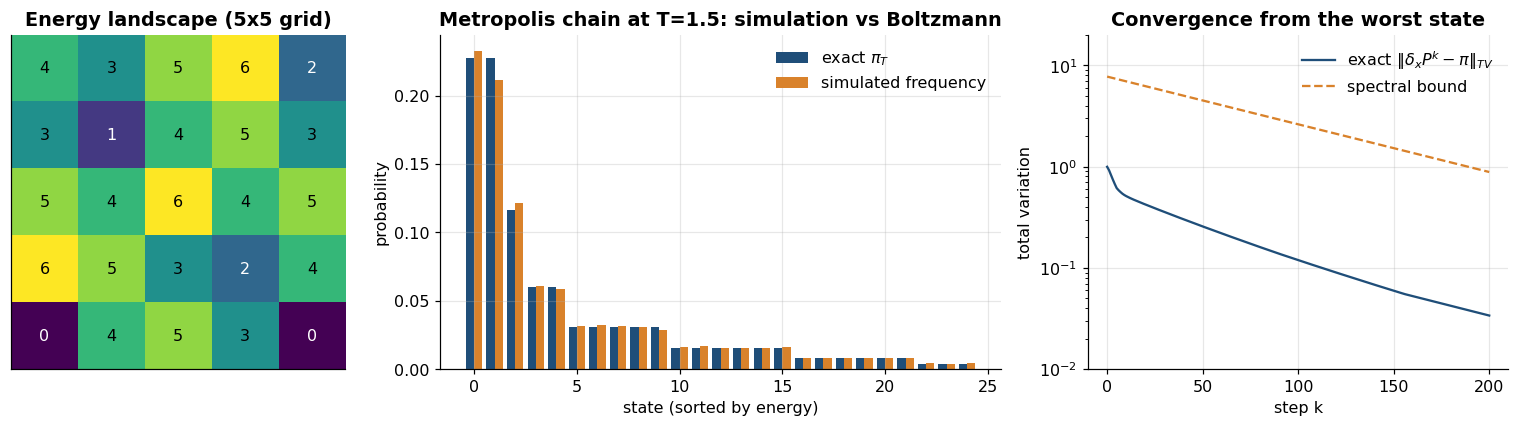

In [4]:
def run_metropolis_chain(E, nbrs_grid, T, n_steps, x0, rng):
    """Lazy symmetric Metropolis chain on the grid; returns visit counts."""
    moves = rng.integers(0, 4, n_steps)
    u = rng.random(n_steps)
    counts = np.zeros(len(E), dtype=np.int64)
    x = x0
    for k in range(n_steps):
        y = nbrs_grid[x][moves[k]]           # -1 encodes "off the grid": stay
        if y >= 0:
            d = E[y] - E[x]
            if d <= 0 or u[k] < np.exp(-d / T):
                x = y
        counts[x] += 1
    return counts


# 4-direction table, -1 where the move leaves the grid
dir_table = []
for i in range(n_states):
    r, c = divmod(i, NC)
    row = []
    for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
        row.append((r + dr) * NC + (c + dc) if (0 <= r + dr < NR and 0 <= c + dc < NC) else -1)
    dir_table.append(row)

N_steps = 300_000
x_start = int(np.argmax(E))
counts = run_metropolis_chain(E, dir_table, T, N_steps, x_start, np.random.default_rng(1))
emp = counts / N_steps
# Markov-chain CLT: sqrt(N)(emp_x - pi_x) -> N(0, sigma_x^2) with the exact asymptotic variance
# sigma^2(f) = 2 <fbar, Z fbar>_pi - Var_pi(f),  Z = (I - P + 1 pi^T)^{-1}  (fundamental matrix; Kemeny & Snell 1960)
Z = np.linalg.inv(np.eye(n_states) - P_lazy + np.outer(np.ones(n_states), pi_T))
sig2 = np.empty(n_states)
for x in range(n_states):
    fbar = (np.arange(n_states) == x) - pi_T[x]
    sig2[x] = 2 * np.sum(pi_T * fbar * (Z @ fbar)) - np.sum(pi_T * fbar**2)
z = (emp - pi_T) / np.sqrt(sig2 / N_steps)
print(f"TV(empirical, Boltzmann) after {N_steps} steps at T={T}: {tv(emp, pi_T):.4f}; "
      f"CLT z-scores: max |z| = {np.abs(z).max():.2f}, mean z^2 = {np.mean(z**2):.2f}")
check_true(np.abs(z).max() < 4.0, "every state frequency within 4 exact CLT standard errors of pi_T(x)")

lam = np.sort(np.abs(np.linalg.eigvals(P_lazy)))[::-1]
lam_star = lam[1]
ks = np.arange(0, 201)
tv_exact, mu = [], np.eye(n_states)[x_start]
for k in ks:
    tv_exact.append(tv(mu, pi_T))
    mu = mu @ P_lazy
tv_exact = np.array(tv_exact)
bound = 0.5 * np.sqrt((1 - pi_T[x_start]) / pi_T[x_start]) * lam_star**ks
check_true(np.all(tv_exact <= bound + 1e-12), "exact TV curve lies below the spectral bound for all k")

fig, ax = plt.subplots(1, 3, figsize=(14, 4.0), gridspec_kw={"width_ratios": [1, 1.6, 1.2]})
im = ax[0].imshow(E_grid, cmap="viridis")
for i in range(n_states):
    r, c = divmod(i, NC)
    ax[0].text(c, r, f"{E[i]:.0f}", ha="center", va="center", color="w" if E[i] < 3 else "k")
ax[0].set_title("Energy landscape (5x5 grid)"); ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].grid(False)
order = np.argsort(E, kind="stable")
xx = np.arange(n_states)
ax[1].bar(xx - 0.2, pi_T[order], width=0.4, label=r"exact $\pi_T$")
ax[1].bar(xx + 0.2, emp[order], width=0.4, label="simulated frequency")
ax[1].set_xlabel("state (sorted by energy)"); ax[1].set_ylabel("probability")
ax[1].set_title(f"Metropolis chain at T={T}: simulation vs Boltzmann"); ax[1].legend()
ax[2].semilogy(ks, tv_exact, label=r"exact $\Vert\delta_x P^k-\pi\Vert_{TV}$")
ax[2].semilogy(ks, bound, "--", label="spectral bound")
ax[2].set_xlabel("step k"); ax[2].set_ylabel("total variation"); ax[2].set_title("Convergence from the worst state")
ax[2].set_ylim(1e-2, 20); ax[2].legend()
plt.tight_layout(); savefig("w2_metropolis_stationary.png"); plt.show()

## 4. Mixing slows exponentially as $T\to 0$

The price of low temperature is slow mixing. For Metropolis dynamics on a finite landscape the spectral gap
$1-\lambda_2(T)$ satisfies $\lim_{T\to 0} T\log(1-\lambda_2(T)) = -m$ with the **critical height**

$$m = \max_{x, y}\big[H(x,y) - E(x) - E(y)\big] + E^{\ast},$$

where $H(x,y)$ is the lowest possible *maximum energy* along a path from $x$ to $y$ (Holley & Stroock 1988;
Holley, Kusuoka & Stroock 1989). So the relaxation time grows like $e^{m/T}$ — an Arrhenius law. Two related
constants appear in this course:

* the **depth** of a local minimum $x$: $d(x) = \min_{y:\,E(y)\lt E(x)} H(x,y) - E(x)$ (how high one must climb to
  find something better); Hajek's constant $d^{\ast}$ is the largest depth of a non-global local minimum;
* $m\ge d^{\ast}$, and $m\gt d^{\ast}$ is possible: with *several* global minima, equilibrating *between* them
  also costs a barrier crossing, although an optimiser does not care which one it finds.

We compute $H$ exactly by a minimax (bottleneck) Floyd–Warshall recursion and compare the slope of
$\log(\text{gap})$ versus $1/T$ with $-m$. Eigenvalues are computed from the symmetrised matrix
$D^{1/2}PD^{-1/2}$ ($D=\mathrm{diag}(\pi_T)$), which is exact for reversible chains and numerically stable.

In [5]:
def bottleneck_heights(E, nbrs):
    """H[x,y] = min over paths x->y of the max energy on the path (minimax Floyd-Warshall)."""
    n = len(E)
    H = np.full((n, n), np.inf)
    for i in range(n):
        H[i, i] = E[i]
        for j in nbrs[i]:
            H[i, j] = max(E[i], E[j])
    for k in range(n):
        H = np.minimum(H, np.maximum(H[:, k, None], H[None, k, :]))
    return H


H = bottleneck_heights(E, nbrs)
depth = {i: H[i][E < E[i]].min() - E[i] for i in local_min if E[i] > E.min()}
d_star = max(depth.values())
m_crit = (H - E[:, None] - E[None, :]).max() + E.min()
print("depths of non-global local minima:", {i: float(v) for i, v in depth.items()}, "-> d* =", d_star, "; critical height m =", m_crit)


def spectral_gap(E, nbrs, T):
    """1 - lambda_2 of the lazy Metropolis chain at temperature T (via the symmetrised matrix)."""
    P = transition_matrix(E, nbrs, T, "lazy")
    s = np.sqrt(boltzmann(E, T))
    S = s[:, None] * P / s[None, :]
    S = 0.5 * (S + S.T)                     # exact symmetry up to rounding
    ev = np.sort(np.linalg.eigvalsh(S))[::-1]
    return 1.0 - ev[1]


T_grid = np.array([0.5, 0.4, 0.33, 0.28, 0.25, 0.22, 0.2, 0.18])
gaps = np.array([spectral_gap(E, nbrs, t) for t in T_grid])
slope = np.polyfit(1 / T_grid[-4:], np.log(gaps[-4:]), 1)[0]
print(f"fitted slope of log(gap) vs 1/T at low T: {slope:.3f}")
check_close(-slope, m_crit, "Arrhenius slope = critical height m (Holley-Stroock)", rtol=0.03, atol=0)

depths of non-global local minima: {4: 3.0, 6: 4.0, 18: 1.0} -> d* = 4.0 ; critical height m = 5.0
fitted slope of log(gap) vs 1/T at low T: -4.990
[PASS] Arrhenius slope = critical height m (Holley-Stroock): got 4.989831, expected 5.0


## 5. Concentration on the global optima as $T\to 0$

Proposition 1 in pictures. We also check the limit value: with $|S^{\ast}| = 2$ tied optima, each should carry mass
$\to 1/2$.

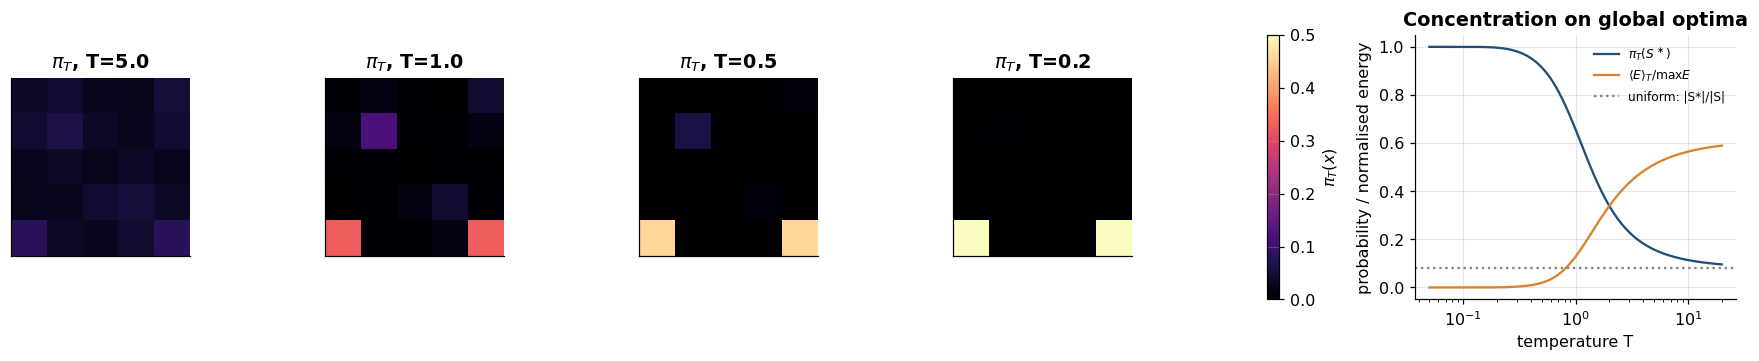

[PASS] pi_T(S*) at T=0.05 = 1.000000 > 0.999
[PASS] limit is uniform on the two tied global minima: got [0.5 0.5], expected [0.5 0.5]
[PASS] T -> infinity gives the uniform distribution (max deviation): got 0.0, expected 0.0


In [6]:
T_show = [5.0, 1.0, 0.5, 0.2]
T_line = np.geomspace(0.05, 20, 200)
p_opt = np.array([boltzmann(E, t)[global_min].sum() for t in T_line])
meanE = np.array([boltzmann(E, t) @ E for t in T_line])

fig, ax = plt.subplots(1, len(T_show) + 2, figsize=(16, 3.4), gridspec_kw={"width_ratios": [1] * len(T_show) + [0.07, 1.8]})
for a, t in zip(ax, T_show):
    im = a.imshow(boltzmann(E, t).reshape(NR, NC), cmap="magma", vmin=0, vmax=0.5)
    a.set_title(f"$\\pi_T$, T={t}"); a.set_xticks([]); a.set_yticks([]); a.grid(False)
ax[-1].semilogx(T_line, p_opt, label=r"$\pi_T(S^\ast)$")
ax[-1].semilogx(T_line, meanE / E.max(), label=r"$\langle E\rangle_T / \max E$")
ax[-1].axhline(len(global_min) / n_states, ls=":", c="grey", label="uniform: |S*|/|S|")
ax[-1].set_xlabel("temperature T"); ax[-1].set_ylabel("probability / normalised energy")
ax[-1].set_title("Concentration on global optima"); ax[-1].legend(fontsize=8)
fig.colorbar(im, cax=ax[len(T_show)], label=r"$\pi_T(x)$")
plt.tight_layout(); savefig("w2_boltzmann_concentration.png"); plt.show()

p_cold = boltzmann(E, 0.05)
check_true(p_cold[global_min].sum() > 0.999, f"pi_T(S*) at T=0.05 = {p_cold[global_min].sum():.6f} > 0.999")
check_close(p_cold[global_min], [0.5, 0.5], "limit is uniform on the two tied global minima", atol=1e-3)
check_close(maxdiff(boltzmann(E, 1e6), 1 / n_states), 0.0, "T -> infinity gives the uniform distribution (max deviation)", atol=1e-6)

## 6. Simulated annealing: the algorithm

SA runs the Metropolis chain while decreasing $T$. A **schedule** maps the step index $k$ to $T_k$. The chain is
then *inhomogeneous*: its transition matrix $P_{T_k}$ changes with $k$. If $T$ decreases slowly enough the chain
tracks $\pi_{T_k}$ (quasi-equilibrium), and since $\pi_{T_k}\to$ uniform on $S^{\ast}$ (Proposition 1) it ends in a
global optimum — Notebook 2 makes "slowly enough" exact.

```text
SimulatedAnnealing(x0, E, propose, schedule T_k, budget B):
    x <- x0 ; Ex <- E(x) ; best <- (x, Ex)
    for k = 1, 2, ... while evaluations < B:
        y  <- propose(x)                     # random neighbour
        Ey <- E(y) ; Δ <- Ey - Ex            # one evaluation (or an O(1) delta)
        if Δ <= 0 or U(0,1) < exp(-Δ / T_k):
            x, Ex <- y, Ey                   # Metropolis acceptance
            if Ex < best.E: best <- (x, Ex)
    return best
```

The implementation below is generic: the problem supplies `energy` and `propose`; the schedule is any callable
$k\mapsto T_k$. Evaluations are counted by `BudgetedObjective`, so SA can be compared with other methods at equal
budgets. The best-so-far point is returned — *not* the final state (a common and costly mistake).

In [7]:
def simulated_annealing(x0, energy, propose, schedule, budget, rng):
    """Generic SA with the Metropolis rule.

    energy   : callable x -> float (wrapped in a BudgetedObjective to count evaluations)
    propose  : callable (x, rng) -> neighbour y (must not modify x)
    schedule : callable k -> T_k > 0 (k = 0, 1, ...)
    Returns (best_x, best_E, obj) where obj holds the evaluation count and best-so-far trace.
    """
    obj = BudgetedObjective(energy, budget)
    x, Ex = x0, obj(x0)
    cur_trace, temps = [Ex], [schedule(0)]
    k = 0
    try:
        while True:
            T = schedule(k)
            y = propose(x, rng)
            Ey = obj(y)
            d = Ey - Ex
            if d <= 0 or rng.random() < np.exp(-d / T):
                x, Ex = y, Ey
            cur_trace.append(Ex); temps.append(T)
            k += 1
    except BudgetExhausted:
        pass
    obj.current_trace, obj.temperatures = np.array(cur_trace), np.array(temps)
    return obj.best_x, obj.best_f, obj


def hill_climb_restarts(n, energy, budget, rng):
    """First-improvement swap local search with random restarts (baseline, same budget)."""
    obj = BudgetedObjective(energy, budget)
    pairs = np.array(np.triu_indices(n, 1)).T
    obj.n_starts = 0
    try:
        while True:
            x = rng.permutation(n); Ex = obj(x)
            obj.n_starts += 1
            improved = True
            while improved:
                improved = False
                for i, j in pairs[rng.permutation(len(pairs))]:
                    y = x.copy(); y[i], y[j] = y[j], y[i]
                    Ey = obj(y)
                    if Ey < Ex:
                        x, Ex, improved = y, Ey, True
                        break
    except BudgetExhausted:
        pass
    return obj.best_x, obj.best_f, obj


def random_search(n, energy, budget, rng):
    """Uniformly random permutations until the budget is spent (baseline)."""
    obj = BudgetedObjective(energy, budget)
    try:
        while True:
            obj(rng.permutation(n))
    except BudgetExhausted:
        pass
    return obj.best_x, obj.best_f, obj


def swap_neighbour(x, rng):
    """Symmetric swap proposal: exchange two distinct random positions (returns a copy)."""
    i, j = rng.choice(len(x), 2, replace=False)
    y = x.copy(); y[i], y[j] = y[j], y[i]
    return y

**Sanity check on the grid, against an exact answer.** SA on the $5\times5$ landscape, started at the deepest
non-global minimum, with a slow geometric schedule from $T_0=5$ should *visit* $S^{\ast}$ (so that the best-so-far
is optimal) in almost all runs. The success probability can be computed **exactly**: make the states of $S^{\ast}$
absorbing and propagate the law of the inhomogeneous chain through the same $1999$ proposals
($P_{T_0}, P_{T_1},\dots$, with the uniform-neighbour proposal used by `grid_propose`); the absorbed mass is
$\Pr(\text{best-so-far}\in S^{\ast})$. The simulated success rate must agree within Monte Carlo error. A $T\equiv0$
run (pure descent) cannot leave the minimum at all, since all its neighbours are higher.

In [8]:
def grid_propose(x, rng):
    return nbrs[x][rng.integers(len(nbrs[x]))]


x_deep = max(depth, key=depth.get)
grid_energy = lambda s: float(E[s])
geo = lambda k: 5.0 * 0.995**k
n_sa_runs, sa_budget = 400, 2000
hits = np.array([simulated_annealing(x_deep, grid_energy, grid_propose, geo, sa_budget, np.random.default_rng(s))[1] == 0
                 for s in range(n_sa_runs)])
# exact: absorbing S*, propagate the law through the proposals made with T_0, ..., T_{budget-2}
mu = np.eye(n_states)[x_deep]
for k in range(sa_budget - 1):
    Pk = transition_matrix(E, nbrs, geo(k), "uniform", hastings=False)
    Pk[global_min] = 0.0; Pk[global_min, global_min] = 1.0
    mu = mu @ Pk
p_exact = mu[global_min].sum()
se_hits = np.sqrt(p_exact * (1 - p_exact) / n_sa_runs)
print(f"SA from the deepest local minimum visits S* in {hits.mean():.1%} of {n_sa_runs} runs; "
      f"exact probability {p_exact:.4f} (binomial s.e. {se_hits:.4f})")
check_true(abs(hits.mean() - p_exact) < 4 * se_hits, "simulated SA success rate = exact absorption probability (4 s.e.)")
check_true(p_exact > 0.95, "the slow geometric schedule escapes the deep minimum with probability > 0.95")
hits0 = [simulated_annealing(x_deep, grid_energy, grid_propose, lambda k: 1e-12, sa_budget, np.random.default_rng(s))[1] == 0
         for s in range(20)]
print(f"T = 0 (pure descent) from the same minimum: {np.mean(hits0):.0%} success")

SA from the deepest local minimum visits S* in 98.5% of 400 runs; exact probability 0.9944 (binomial s.e. 0.0037)
[PASS] simulated SA success rate = exact absorption probability (4 s.e.)
[PASS] the slow geometric schedule escapes the deep minimum with probability > 0.95


T = 0 (pure descent) from the same minimum: 0% success


## 7. SA versus exact optimum on the quadratic assignment problem

The QAP places $n$ facilities on $n$ locations to minimise $\sum_{ij} F_{ij} D_{\pi(i)\pi(j)}$; it is NP-hard and
notoriously hard to approximate (Sahni & Gonzalez 1976). With $n=8$ the $8! = 40320$ permutations can be enumerated,
so `qap_brute_force` gives the exact optimum. We compare, at an **equal budget of 1500 evaluations**
(3.7% of the search space):

* **SA** with the swap neighbourhood and a geometric schedule $T_k = T_0\,\alpha^k$, where $T_0$ is the mean
  absolute $\Delta$ of 50 random swaps from a random permutation (the start and those 50 probe evaluations are
  charged to the SA budget by running SA with the remaining $1500-51$ evaluations), and $T_{\text{end}} = T_0/200$;
* **hill climbing with random restarts** (first-improvement, swap neighbourhood);
* **random search** (uniform permutations).

5 random instances $\times$ 12 seeds per method. Success = exact optimum found.

In [9]:
n_qap, budget, n_inst, n_seeds = 8, 1500, 5, 12
inst_rng = np.random.default_rng(2024)
instances = []
for _ in range(n_inst):
    F, Dm = random_qap(n_qap, inst_rng)
    opt, _ = qap_brute_force(F, Dm)
    instances.append((F, Dm, opt))
print("exact optima:", [round(o, 2) for _, _, o in instances])


def sa_qap(F, Dm, budget, rng, n_probe=50):
    """SA for the QAP: T0 from n_probe random swaps, geometric cooling to T0/200; total budget includes the probes."""
    energy = lambda p: qap_cost(p, F, Dm)
    x = rng.permutation(len(F)); Ex = energy(x)
    deltas = [abs(energy(swap_neighbour(x, rng)) - Ex) for _ in range(n_probe)]
    T0 = np.mean(deltas)
    rest = budget - n_probe - 1
    alpha = (1 / 200) ** (1 / rest)
    bx, bE, obj = simulated_annealing(x, energy, swap_neighbour, lambda k: T0 * alpha**k, rest, rng)
    return bx, min(bE, Ex), obj


methods = {
    "SA (geometric)": lambda F, Dm, r: sa_qap(F, Dm, budget, r),
    "HC + restarts": lambda F, Dm, r: hill_climb_restarts(n_qap, lambda p: qap_cost(p, F, Dm), budget, r),
    "random search": lambda F, Dm, r: random_search(n_qap, lambda p: qap_cost(p, F, Dm), budget, r),
}
gaps_qap = {m: np.zeros((n_inst, n_seeds)) for m in methods}
hc_starts = []
for m, fn in methods.items():
    for a, (F, Dm, opt) in enumerate(instances):
        for s in range(n_seeds):
            _, bE, o = fn(F, Dm, np.random.default_rng(1000 * a + s))
            gaps_qap[m][a, s] = (bE - opt) / opt
            if m == "HC + restarts":
                hc_starts.append(o.n_starts)
print(f"HC + restarts performs {np.mean(hc_starts):.1f} descents per run on average "
      f"(~{budget / np.mean(hc_starts):.0f} evaluations per descent)")
for m, g in gaps_qap.items():
    q1, med, q3 = np.percentile(g, [25, 50, 75])
    print(f"{m:15s} success rate {np.mean(g < 1e-9):6.1%}   gap median {100*med:.2f}%  IQR [{100*q1:.2f}, {100*q3:.2f}]%")
check_true(np.all(np.concatenate([g.ravel() for g in gaps_qap.values()]) >= -1e-12),
           "no method reports a cost below the exact optimum (consistency of the exact solver)")

exact optima: [927.4, 831.68, 763.24, 1308.52, 1137.28]


HC + restarts performs 19.2 descents per run on average (~78 evaluations per descent)
SA (geometric)  success rate  48.3%   gap median 0.13%  IQR [0.00, 0.82]%
HC + restarts   success rate  98.3%   gap median 0.00%  IQR [0.00, 0.00]%
random search   success rate   3.3%   gap median 1.96%  IQR [0.92, 3.64]%
[PASS] no method reports a cost below the exact optimum (consistency of the exact solver)


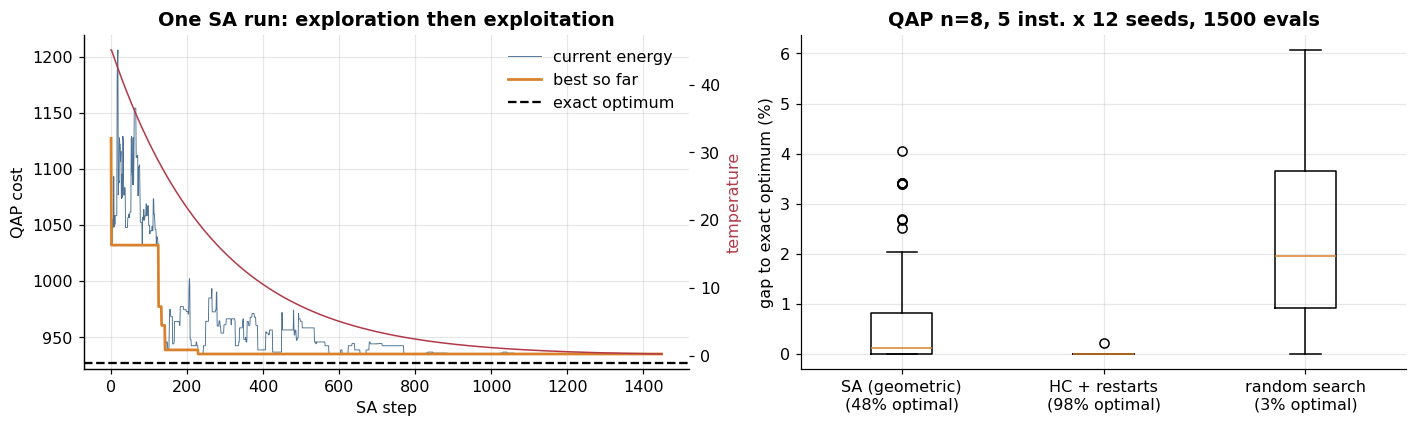

In [10]:
# a single SA run, instrumented, on instance 0
F, Dm, opt = instances[0]
_, _, obj = sa_qap(F, Dm, budget, np.random.default_rng(7))
ev, best = obj.trace()            # SA's own objective: one entry per SA evaluation, aligned with current_trace
assert len(best) == len(obj.current_trace)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(obj.current_trace, lw=0.6, alpha=0.8, label="current energy")
ax[0].plot(best, lw=1.8, label="best so far")
ax[0].axhline(opt, ls="--", c="k", label="exact optimum")
ax0b = ax[0].twinx(); ax0b.plot(obj.temperatures, c=PALETTE["red"], lw=1); ax0b.set_ylabel("temperature", color=PALETTE["red"])
ax0b.grid(False)
ax[0].set_xlabel("SA step"); ax[0].set_ylabel("QAP cost"); ax[0].set_title("One SA run: exploration then exploitation")
ax[0].legend(loc="upper right")
data = [100 * gaps_qap[m].ravel() for m in methods]
ax[1].boxplot(data, showfliers=True)
ax[1].set_xticks(range(1, len(methods) + 1), [f"{m}\n({np.mean(gaps_qap[m] < 1e-9):.0%} optimal)" for m in methods])
ax[1].set_ylabel("gap to exact optimum (%)"); ax[1].set_title(f"QAP n={n_qap}, {n_inst} inst. x {n_seeds} seeds, {budget} evals")
plt.tight_layout(); savefig("w2_sa_qap.png"); plt.show()

**Reading the results — an honest negative.** SA is far better than random search, and its median gap is small,
but on this *tiny* space **hill climbing with random restarts finds the exact optimum more often**. The reason is
quantitative: a descent costs only ~80 evaluations (printed above), so each run gets ~19 independent descents. If a
fraction $p$ of random starts descends into the optimum's basin, restarts succeed with probability $1-(1-p)^{19}$;
the observed success rate implies $p$ of roughly $0.2$ — large basins on a small space. A single SA trajectory
instead spends most of its budget in the hot phase (see the trace: large fluctuations at high $T$, then a frozen
phase where SA behaves like a randomised descent). SA pays off when local optima are numerous and basins are
small relative to the budget — the regime of Notebook 2 (spin glasses with $2^{100}$ states) and of the lab (TSP
with $n\ge 100$). Always keep restarted local search as a baseline: it is often embarrassingly strong.

**AI relevance.** The same generic loop — propose a local modification, evaluate, accept by a Metropolis-type rule
— is used for discrete hyperparameter and architecture search, for feature-subset selection, and for
search over programs or prompts, where the "energy" is a validation loss and each evaluation is expensive, which
is why every comparison is at equal evaluation budget. MCMC samplers used for Bayesian neural networks are the
fixed-$T$ version of the same chain.

## Key takeaways

- The Metropolis rule $\min(1,e^{-\Delta/T})$ with a symmetric proposal makes the Boltzmann distribution
  $\pi_T\propto e^{-E/T}$ stationary by **detailed balance**; with asymmetric proposals the Hastings factor
  $q(y,x)/q(x,y)$ is mandatory — we saw the stationary law become $\propto\deg(x)e^{-E/T}$ without it.
- The exact transition matrix, its eigenvector, the closed form and a $3\times10^5$-step simulation all agree.
- $\pi_T$ concentrates uniformly on the set of global minima as $T\to0$, but the **spectral gap closes like
  $e^{-m/T}$** — the exploration/exploitation tension of SA is a quantitative Arrhenius law.
- SA is an inhomogeneous Markov chain; returning the best-so-far point and counting evaluations are part of a
  correct implementation.
- At equal budgets on exactly-solved $n=8$ QAP instances SA crushes random search but loses to
  hill climbing with restarts: on small landscapes with large basins, restarts are a very strong baseline.

## Exercises

1. ★ Show that the Barker rule $\alpha(x,y) = \pi(y)/(\pi(x)+\pi(y))$ (symmetric proposal) also satisfies detailed
   balance. Implement it on the grid, verify its stationary vector, and compare its spectral gap with Metropolis at
   $T\in\lbrace 0.5, 1.5\rbrace$. (Peskun 1973 predicts which is larger — why?)
2. ★ Prove that the matrix $D^{1/2} P D^{-1/2}$ with $D=\mathrm{diag}(\pi)$ is symmetric iff $P$ is reversible
   with respect to $\pi$, and deduce that all eigenvalues of a reversible $P$ are real.
3. ★★ Prove the spectral bound $4\Vert\delta_xP^k-\pi\Vert_{TV}^2 \le \frac{1-\pi(x)}{\pi(x)}\lambda_\ast^{2k}$ used in
   Section 3, starting from the eigen-expansion of $P^k(x,\cdot)/\pi(\cdot)$ in $\ell^2(\pi)$.
4. ★★ Modify the energy grid so that the global minimum is unique, recompute $d^{\ast}$ and $m$, and check
   numerically that the Arrhenius slope now equals the new $m$. Construct a landscape with $m = d^{\ast}$ and one
   with $m \gt d^{\ast}$ and a unique global minimum — is the latter possible? Prove your answer.
5. ★★ Replace the swap neighbourhood for the QAP by an insertion (shift) neighbourhood. Is the proposal still
   symmetric? Measure SA success rates at the same budget and explain the difference.
6. ★★★ For the grid landscape, compute the exact distribution of SA at step $k$ by multiplying the time-varying
   matrices $P_{T_1}P_{T_2}\cdots P_{T_k}$ for geometric schedules with different $\alpha$, and plot
   $\Vert\mu_k-\pi_{T_k}\Vert_{TV}$ (the *lag* behind quasi-equilibrium) and $\mu_k(S^{\ast})$. Find the
   fastest schedule that keeps the final $\mu_K(S^{\ast})\ge 0.95$.